In [5]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np
import os
%load_ext autoreload
%autoreload 2

In [63]:
import json
from pprint import pprint

paths = {
    "minmax og": r'jobs\20251022_171601\exp-fc1-minmax-ep10000-bs2048-lr1e-3-s42-h512-256-128',
    "zscore std dev 0": r'jobs\20251110_122808\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128',
    "zscore std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "zscore std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "slopes on 0 std dev": r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000",
    "log on std dev 0": r"RL\jobs\20251121_234325\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "log on std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234345\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "log on std dev 1e-7": r"jobs\20251121_234356\exp-fc1-log-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "split vector std dev 5e-8": r"A:\Projects\DM + RL\RL\jobs\20251121_234746\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "split vector std dev 1e-7": r"A:\Projects\DM + RL\RL\jobs\20251121_234754\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
    "split vector std dev 0": r"A:\Projects\DM + RL\RL\jobs\20251121_234802\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000",
}

path = paths["split vector std dev 0"]
# path = r'jobs\20251111_165459\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128'
# path = r'jobs\20251115_225402\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h1024-512-256-images'
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012420\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_012429\exp-fc1-zscore-ep2500-bs262144-lr1e-3-s42-h512-256-128-images"

# model1
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_092705\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# # model2
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134444\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-images-dc100000"

# model3 (slopes)
# path = r"A:\Projects\DM + RL\RL\jobs\20251117_134718\exp-fc1-zscore-ep10000-bs2048-lr1e-3-s42-h512-256-128-slopes-dc100000"

metrics_path = path + r'\metrics.json'

with open(metrics_path, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

pprint(metrics_data.keys())

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])


In [64]:
metrics_data['dataset_meta']

{'environment_config': {'telescope_diameter': 8.0,
  'oversizing_factor': 1.0666666666666667,
  'wavelength_sci': 2.2e-06,
  'num_modes': 25,
  'zero_magnitude_flux': 389999999.99999994,
  'stellar_magnitude': 5.0,
  'env_delta_t': 0.001,
  'pixels': 64,
  'num_iterations': 10,
  'coronagraph_charge': 6,
  'num_airy': 5,
  'pixels_per_spacial_res': 2,
  'num_noise_modes': 10,
  'diversity_enabled': True,
  'nudge_magnitude': 3e-07,
  'nudge_mode_indices': [3],
  'num_diversity_pairs': 1,
  'obs_noise_enabled': False,
  'obs_delta_t': 0.001,
  'include_slopes': True,
  'action_scale': 1e-08,
  'dm_clip': None,
  'lyot_fraction': 0.8,
  'basis': 'zernike'},
 'dataset_config': {'N': 220000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0

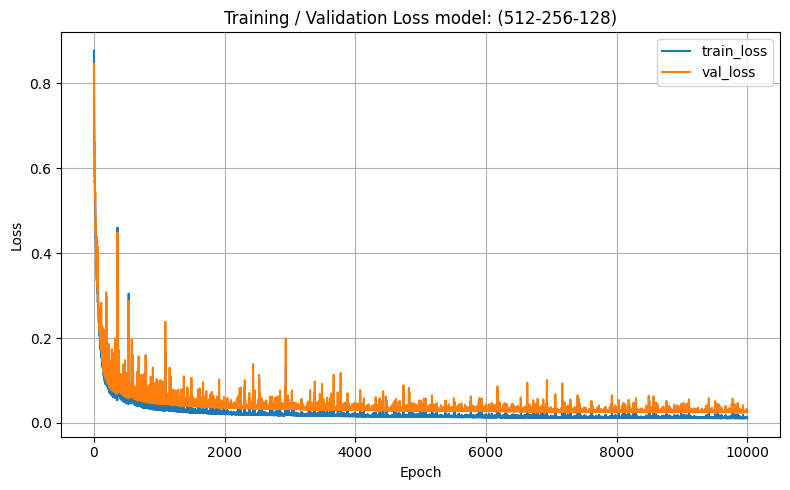

In [65]:
history = metrics_data['history']
train = history.get('train_loss', [])
val = history.get('val_loss', [])

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train)+1), train, label='train_loss')
if val:
    plt.plot(range(1, len(val)+1), val, label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training / Validation Loss model: (512-256-128)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [66]:
import glob
import numpy as np

# search for .pth/.pt files in the experiment directory (uses existing `path` variable)
candidates = glob.glob(os.path.join(path, '*.pth')) + glob.glob(os.path.join(path, '*.pt'))
if not candidates:
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(('.pth', '.pt')):
                candidates.append(os.path.join(root, f))

if not candidates:
    raise FileNotFoundError(f'No .pth/.pt files found under {path!r}')

checkpoint_path = max(candidates, key=os.path.getmtime)


In [67]:
metrics_data['y_norm']

{'mean': 0.0, 'std': 1.0}

In [68]:
metrics_data.keys()

dict_keys(['args', 'x_norm', 'y_norm', 'history', 'input_shape', 'output_dim', 'dataset_meta', 'train_job_meta'])

In [69]:
metrics_data['dataset_meta']

{'environment_config': {'telescope_diameter': 8.0,
  'oversizing_factor': 1.0666666666666667,
  'wavelength_sci': 2.2e-06,
  'num_modes': 25,
  'zero_magnitude_flux': 389999999.99999994,
  'stellar_magnitude': 5.0,
  'env_delta_t': 0.001,
  'pixels': 64,
  'num_iterations': 10,
  'coronagraph_charge': 6,
  'num_airy': 5,
  'pixels_per_spacial_res': 2,
  'num_noise_modes': 10,
  'diversity_enabled': True,
  'nudge_magnitude': 3e-07,
  'nudge_mode_indices': [3],
  'num_diversity_pairs': 1,
  'obs_noise_enabled': False,
  'obs_delta_t': 0.001,
  'include_slopes': True,
  'action_scale': 1e-08,
  'dm_clip': None,
  'lyot_fraction': 0.8,
  'basis': 'zernike'},
 'dataset_config': {'N': 220000,
  'delta_t': 0.001,
  'noise_enabled': False,
  'dm_random_noise': 1e-07,
  'nudge_amplitude': 3e-07,
  'nudge_mode_index': 0,
  'save_checkpoints': None},
 'nudge_vector': [3e-07,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0

In [70]:
metrics_data['input_shape']

[20, 20, 3]

In [71]:
from archs.fc1 import FC1
import torch

model = FC1(
    final_output_dim=metrics_data['output_dim'], 
    image_input_shape=metrics_data['input_shape'], 
    hidden_layers=metrics_data['args']['fc1_hidden'], 
    activation=metrics_data['args']['fc1_activation'],
    final_activation=metrics_data['args']['fc1_final_activation']    
    )
model.load_state_dict(torch.load(checkpoint_path))
model.eval()

FC1(
  (final_net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1200, out_features=512, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.01)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Linear(in_features=128, out_features=26, bias=True)
    (8): LeakyReLU(negative_slope=0.01)
  )
)

In [72]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 782490


In [73]:
from environment import CoronagraphEnvironment

env_config = metrics_data['dataset_meta']['environment_config']
if 'pixel_resolution' in env_config:
    env_config['pixels'] = env_config.pop('pixel_resolution')
if 'ppsr' in env_config:
    env_config['pixels_per_spacial_res'] = env_config.pop('ppsr')
if 'env_delta_t' in env_config:
    env_config['delta_t'] = env_config.pop('env_delta_t')

env = CoronagraphEnvironment(**env_config)

initializing coronagraph env. might take a minute.


In [74]:
import pickle
from pathlib import Path

dataset_path = Path(r'data\dataset100K25M_zernike.pkl')
if not dataset_path.exists():
    raise FileNotFoundError(f"{dataset_path} not found")

with dataset_path.open('rb') as f:
    dataset = pickle.load(f)

print("Loaded:", dataset_path)
print("Type:", type(dataset))

if isinstance(dataset, dict):
    print("Keys:", list(dataset.keys()))
elif isinstance(dataset, (list, tuple)):
    print("Length:", len(dataset))
else:
    try:
        arr = np.asarray(dataset)  # np imported in another cell
        print("As numpy array shape:", arr.shape)
    except Exception:
        pass

# show a small preview without dumping everything
if isinstance(dataset, dict):
    for k in list(dataset.keys())[:10]:
        v = dataset[k]
        if isinstance(v, (list, tuple)):
            print(f"{k}: list len={len(v)}")
        else:
            print(f"{k}: type={type(v)}")
elif isinstance(dataset, (list, tuple)) and len(dataset):
    print("First element type:", type(dataset[0]))
    try:
        preview = dataset[0]
        if isinstance(preview, (list, tuple, dict, np.ndarray)):
            print("Preview (first element):", (preview if isinstance(preview, dict) else (np.asarray(preview).shape if hasattr(preview, '__len__') else type(preview))))
        else:
            print("Preview (first element):", preview)
    except Exception:
        pass

Loaded: data\dataset100K25M_zernike.pkl
Type: <class 'dict'>
Keys: ['dm_settings', 'images', 'meta']
dm_settings: list len=100000
images: list len=100000
meta: type=<class 'dict'>


In [75]:
pprint(dataset['meta'])
env_config

{'dataset_config': {'N': 100000,
                    'delta_t': 0.001,
                    'dm_random_noise': 1e-07,
                    'noise_enabled': False,
                    'nudge_amplitude': 3e-07,
                    'nudge_mode_index': 0,
                    'save_checkpoints': None},
 'environment_config': {'basis': 'zernike',
                        'coronagraph_charge': 6,
                        'num_airy': 5,
                        'num_modes': 25,
                        'oversizing_factor': 1,
                        'pixel_resolution': 64,
                        'ppsr': 2},
 'image_triplet_description': '(baseline, +nudge, -nudge)',
 'nudge_vector': array([3.e-07, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00, 0.e+00,
       0.e+00]),
 'num_samples': 100000}


{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 5,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'zernike',
 'delta_t': 0.001}

In [76]:
new_imgs = dataset['images']

In [77]:
dataset['dm_settings'][10]

array([-1.11083251e-07,  2.54725751e-08, -1.69676380e-08,  1.02825129e-07,
       -2.90437491e-08,  1.35678267e-08, -1.08690941e-11, -8.40652663e-08,
       -8.11033433e-09,  6.78907005e-09, -5.38797572e-08, -4.76340607e-08,
       -5.88002651e-09,  1.94911619e-08, -3.54229079e-08, -6.30878785e-08,
       -3.44703922e-08,  5.15971790e-09,  1.54343871e-08, -5.44520162e-08,
       -1.92254539e-08,  1.48494470e-09,  2.06377637e-09,  4.18741163e-08,
        2.42270709e-08])

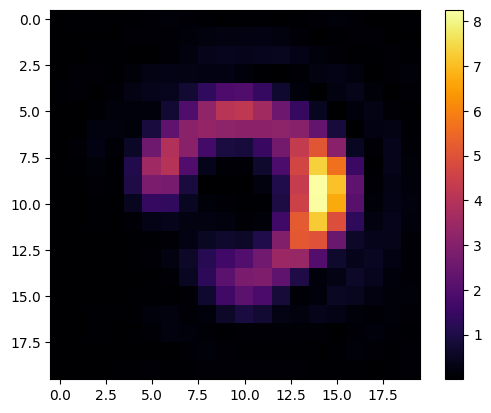

In [78]:
plt.imshow(new_imgs[6][2], cmap='inferno')
plt.colorbar()
plt.show()

In [79]:
TEST_INDEX = 5

In [80]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

TEST_INDEX += 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        # env.deformable_mirror.flatten()
        # env.set_random_dm(noise=dm_random_noise)
        # original = env.deformable_mirror.actuators.copy()
        original = dataset['dm_settings'][TEST_INDEX]
        env.set_dm(action=original)

        original_contrast = env.get_contrast(delta_t=1e15)

        img1 = new_imgs[TEST_INDEX][0]


        img2 = new_imgs[TEST_INDEX][1]

        # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        img3 = new_imgs[TEST_INDEX][2]
        # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs, dtype=torch.float).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(img1, cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()



imgs_norm.shape = torch.Size([1, 20, 20, 3])


ValueError: operands could not be broadcast together with shapes (1,26) (25,) 

C:\Users\alexe\AppData\Local\Temp\ipykernel_19184\4242610055.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  prediction_magnitudes.append(np.abs(pred_mag))
C:\Users\alexe\AppData\Local\Temp\ipykernel_19184\4242610055.py:70: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


Noise level: 1e-08
  avg prediction magnitude: 0.0010873673018068075
  avg contrast improvement: -250035.4755420146
  avg cosine similarity: -0.03963323400045435
Noise level: 5e-08
  avg prediction magnitude: 0.0010753540555015206
  avg contrast improvement: -10972.056580954331
  avg cosine similarity: -0.051515557973956065
Noise level: 1e-07
  avg prediction magnitude: 0.0010659907711669803
  avg contrast improvement: -2029.907337087465
  avg cosine similarity: -0.05608993891833557
Noise level: 2e-07
  avg prediction magnitude: 0.0010214288486167789
  avg contrast improvement: -537.5678935531621
  avg cosine similarity: -0.012746873051704218
Noise level: 3e-07
  avg prediction magnitude: 0.0009126026998274028
  avg contrast improvement: -165.9268457588651
  avg cosine similarity: 0.014946430781856179
Noise level: 4e-07
  avg prediction magnitude: 0.0008417432545684278
  avg contrast improvement: -65.4619426146983
  avg cosine similarity: 0.05294545049934338


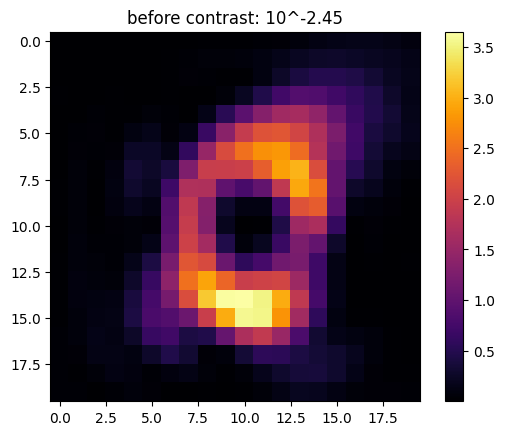

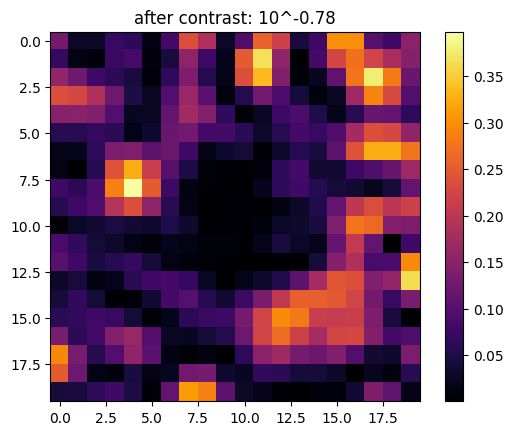

In [81]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 30

train_type = metrics_data['args']['train_type']
slopes_train = (train_type == "slopes")

split_vector = metrics_data['args'].get('split_vector', False)

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

similarities = []

noise_levels = [1e-8, 5e-8, 1e-7, 2e-7, 3e-7, 4e-7]

for noise in noise_levels:
    prediction_magnitudes = []
    contrast_differences = []

    for _ in range(N):
            env.deformable_mirror.flatten()
            # env.noise_gen_mirror.flatten()
            env.set_random_dm(noise=noise)
            env.set_nudge_vectors(vectors=[nudge_vec])
            original = env.deformable_mirror.actuators.copy()

            original_contrast = env.get_contrast(delta_t=1e15)

            imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

            slopes = env.get_slopes()
            
            with torch.no_grad():
                if slopes_train:
                    slopes = torch.asarray(slopes, dtype=torch.float).unsqueeze(0).unsqueeze(-1)
                    imgs_norm, _ = x_norm_func(slopes, **params)
                else:
                    imgs = torch.asarray(imgs).unsqueeze(0)
                    imgs_norm, _ = x_norm_func(imgs, **params)
                
                
                imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
                y_pred = model(imgs_norm)

                y_pred = y_pred.squeeze(0)                     

                pred_mag = np.linalg.norm(y_pred) if not split_vector else y_pred[-1]
                prediction_magnitudes.append(np.abs(pred_mag))

                if split_vector:
                     y_pred = y_pred[:-1]
                y_pred *= y_std
                y_pred -= y_mean


            orig_t = torch.as_tensor(original, dtype=y_pred.dtype, device=y_pred.device).unsqueeze(0)
            cos_sim = torch.nn.functional.cosine_similarity(y_pred, orig_t, dim=1).item()
            similarities.append(cos_sim)
            # print(f"cosine_similarity: {cos_sim:.6f}")

            env.deformable_mirror.flatten()
            env.deformable_mirror.actuators = original - np.array(y_pred[0])
            new_contrast = env.get_contrast(delta_t=1e15)
            contrast_differences.append((original_contrast - new_contrast) / original_contrast)


    print(f"Noise level: {noise}")
    print(f"  avg prediction magnitude: {np.mean(prediction_magnitudes)}")
    print(f"  avg contrast improvement: {np.mean(contrast_differences)}")
    print(f"  avg cosine similarity: {np.mean(similarities)}")

# print(f"avg prediction magnitude: {np.mean(prediction_magnitudes)}")
# print(f"avg contrast improvement: {np.mean(contrast_differences)}")
# print(f"avg cosine similarity: {np.mean(similarities)}")

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(imgs[0][0] if not slopes_train else imgs[0], cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()

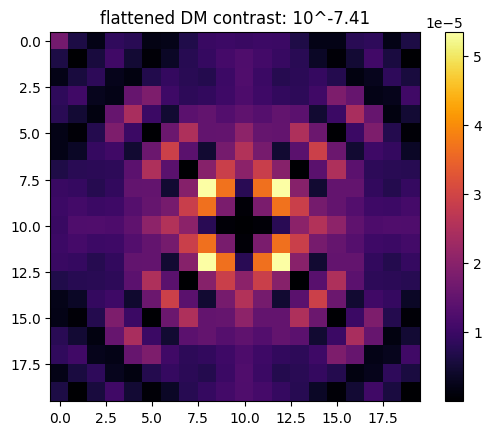

In [52]:
env.deformable_mirror.flatten()
img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(img4, cmap='inferno')
plt.title(f"flattened DM contrast: 10^{np.log10(env.get_contrast(delta_t=delta_t)):.02f}")
plt.colorbar()
plt.show()

### Visualizing the adverserial image generation process.

C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\1900727497.py:55: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


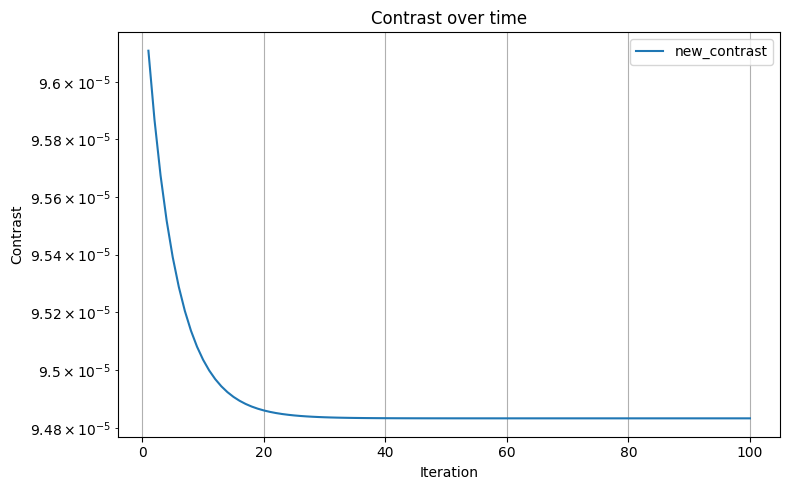

Minimum Contrast: 9.48343306869618e-05
Noise level: 1e-07
  avg prediction magnitude: 0.05637024715542793
  avg contrast improvement: 0.00016444682204658928
avg prediction magnitude: 0.05637024715542793
avg contrast improvement: 0.00016444682204658928


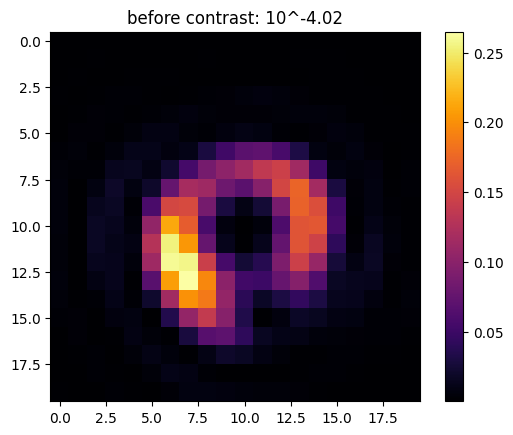

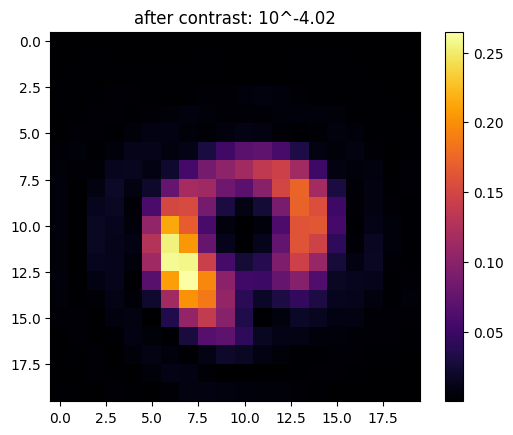

In [1159]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

N = 100
output_scaling = 0.05
noise_levels = [1e-7] # [1e-8, 5e-8, 1e-7, 2e-7, 3e-7, 4e-7]

for noise in noise_levels:
    prediction_magnitudes = []
    contrast_differences = []
    env.deformable_mirror.flatten()
    env.set_random_dm(noise=noise)

    contrasts = []


    for i in range(N):
            # env.deformable_mirror.flatten()
            # env.noise_gen_mirror.flatten()
            # env.set_random_dm(noise=noise)
            env.set_nudge_vectors(vectors=[nudge_vec])
            original = env.deformable_mirror.actuators.copy()

            original_contrast = env.get_contrast(delta_t=1e15)

            imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
            
            with torch.no_grad():
                imgs = torch.asarray(imgs).unsqueeze(0)
                
                imgs_norm, _ = x_norm_func(imgs, **params)
                imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
                y_pred = model(imgs_norm)

                pred_mag = np.linalg.norm(y_pred)
                prediction_magnitudes.append(pred_mag)

                y_pred *= y_std
                y_pred -= y_mean

                y_pred *= output_scaling ** ((i + 1) / 15)

            
            env.deformable_mirror.flatten()
            env.deformable_mirror.actuators = original - np.array(y_pred[0])
            new_contrast = env.get_contrast(delta_t=1e15)
            contrast_differences.append((original_contrast - new_contrast) / original_contrast)
            contrasts.append(new_contrast)

    plt.figure(figsize=(8,5))
    plt.plot(range(1, len(contrasts)+1), contrasts, label='new_contrast')
    plt.xlabel('Iteration')
    plt.ylabel('Contrast')
    plt.title('Contrast over time')
    plt.legend()
    plt.yscale('log')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Minimum Contrast: {np.min(contrasts)}")

    print(f"Noise level: {noise}")
    print(f"  avg prediction magnitude: {np.mean(prediction_magnitudes)}")
    print(f"  avg contrast improvement: {np.mean(contrast_differences)}")


print(f"avg prediction magnitude: {np.mean(prediction_magnitudes)}")
print(f"avg contrast improvement: {np.mean(contrast_differences)}")

img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
plt.imshow(imgs[0][0], cmap='inferno')
plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
plt.colorbar()
plt.show()

plt.imshow(img4, cmap='inferno')
plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
plt.colorbar()
plt.show()

### Fitting a generalizer model

In [1160]:
from train_job import NORMALIZERS
from scipy.optimize import minimize_scalar

def contrast_for_noise(noise_level, output_scaling=1, N=100):
    nudge_vec = metrics_data['dataset_meta']['nudge_vector']
    delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']

    x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
    params = metrics_data['x_norm'].copy()
    params.pop('type')

    y_mean = metrics_data['y_norm']['mean']
    y_std = metrics_data['y_norm']['std']

    prediction_magnitudes = []
    contrast_differences = []
    contrasts = []
    
    for _ in range(N):
        env.deformable_mirror.flatten()
        # env.noise_gen_mirror.flatten()
        env.set_random_dm(noise=noise_level)
        env.set_nudge_vectors(vectors=[nudge_vec])
        original = env.deformable_mirror.actuators.copy()
        original_contrast = env.get_contrast(delta_t=1e15)
        imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

        with torch.no_grad():
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            y_pred = model(imgs_norm)

            pred_mag = np.linalg.norm(y_pred)
            prediction_magnitudes.append(pred_mag)

            y_pred *= y_std
            y_pred -= y_mean

            pred_vec = y_pred[0].cpu().numpy()
            cos_sim = float(np.dot(pred_vec, original) / ((np.linalg.norm(pred_vec) * np.linalg.norm(original)) + 1e-15))
            print(f"cosine_similarity: {cos_sim:.6f}")

            y_pred *= output_scaling
        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)
        contrast_differences.append((original_contrast - new_contrast) / original_contrast)
        contrasts.append(new_contrast)

    return np.mean(contrast_differences)



def objective(x):
    return contrast_for_noise(2e-7, output_scaling=x, N=50)

In [1172]:
contrast_for_noise(1e-7, output_scaling=1.07, N=50)

cosine_similarity: 0.035625
cosine_similarity: 0.027163
cosine_similarity: -0.003029


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\2170253478.py:48: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


cosine_similarity: 0.044060
cosine_similarity: 0.008674
cosine_similarity: 0.024855
cosine_similarity: 0.025492
cosine_similarity: 0.118652
cosine_similarity: 0.069625
cosine_similarity: -0.055365
cosine_similarity: -0.033023
cosine_similarity: 0.124657
cosine_similarity: 0.025145
cosine_similarity: 0.061549
cosine_similarity: -0.212706
cosine_similarity: -0.012906
cosine_similarity: -0.064831
cosine_similarity: -0.022270
cosine_similarity: -0.121541
cosine_similarity: -0.062726
cosine_similarity: 0.073732
cosine_similarity: 0.010638
cosine_similarity: -0.133168
cosine_similarity: 0.002484
cosine_similarity: -0.005153
cosine_similarity: 0.037229
cosine_similarity: 0.185813
cosine_similarity: -0.116501
cosine_similarity: -0.022940
cosine_similarity: 0.064113
cosine_similarity: 0.018393
cosine_similarity: 0.081112
cosine_similarity: 0.064363
cosine_similarity: 0.074994
cosine_similarity: 0.057173
cosine_similarity: 0.120993
cosine_similarity: 0.003974
cosine_similarity: -0.000337
cosine_

np.float64(0.0010253038449224287)

In [1071]:
values = np.linspace(0.05, 0.06, 11)
results = [objective(x) for x in values]

C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3770640076.py:44: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


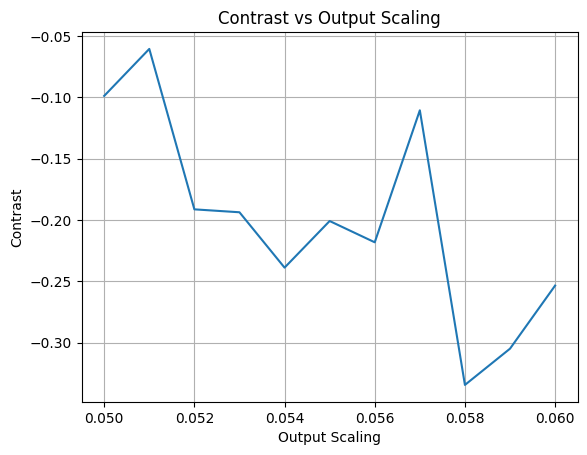

In [1073]:
plt.plot(values, results)
plt.xlabel('Output Scaling')
plt.ylabel('Contrast')
plt.title('Contrast vs Output Scaling')
plt.grid(True)
plt.show()


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\1294762368.py:44: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


np.float64(2.1484673253902226e-05)

In [908]:
# prediction_magnitudes = []
# contrast_differences = []

# for _ in range(N):
#         env.deformable_mirror.flatten()
#         # env.noise_gen_mirror.flatten()
#         env.set_random_dm(noise=1e-8)
#         env.set_nudge_vectors(vectors=[nudge_vec])
#         original = env.deformable_mirror.actuators.copy()

#         original_contrast = env.get_contrast(delta_t=1e15)

#         imgs = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)
#         # img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

#         # env.deformable_mirror.flatten()
#         # env.deformable_mirror.actuators = original + nudge_vec
#         # img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

#         # env.deformable_mirror.flatten()
#         # env.deformable_mirror.actuators = original - nudge_vec
#         # img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
#         with torch.no_grad():
#             # imgs = np.array([img1, img2, img3])
#             imgs = torch.asarray(imgs).unsqueeze(0)
            
#             imgs_norm, _ = x_norm_func(imgs, **params)
#             imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
#             # print(f"imgs_norm.shape = {imgs_norm.shape}")
#             y_pred = model(imgs_norm)

#             pred_mag = np.linalg.norm(y_pred)
#             prediction_magnitudes.append(pred_mag)

#             # print(f"Magnitude of prediction: {pred_mag}")

#             # print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / (y_std + 1e-12))}")

#             y_pred *= y_std
#             y_pred -= y_mean

#             # print(y_pred)
#             # print(original)

        
#         env.deformable_mirror.flatten()
#         env.deformable_mirror.actuators = original - np.array(y_pred[0])
#         new_contrast = env.get_contrast(delta_t=1e15)
#         contrast_differences.append(original_contrast - new_contrast)


In [909]:
env.deformable_mirror.flatten()
env.noise_gen_mirror.flatten()
np.log10(env.get_contrast(delta_t=1e15))

np.float64(-7.410747733694092)

imgs_norm.shape = torch.Size([1, 20, 20, 3])
MSE: 0.044697978409293994
tensor([[-2.3291e-09, -1.9976e-09, -2.6975e-10, -3.6407e-09, -3.4723e-10,
         -2.7729e-10, -2.5120e-09, -3.8300e-10, -9.2089e-10, -4.2177e-10,
         -6.5898e-10, -1.0145e-09, -8.6252e-10, -4.8792e-10, -3.4647e-10,
         -3.5958e-10, -1.0569e-09, -6.9763e-10, -6.6513e-10, -3.4095e-10,
         -1.7764e-10, -5.1215e-10, -3.3113e-10, -1.5990e-10, -5.9892e-10]])
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3645116021.py:44: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")
C:\Users\alexe\AppData\Local\Temp\ipykernel_12096\3645116021.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  env.deformable_mirror.actuators = original - np.array(y_pred[0])


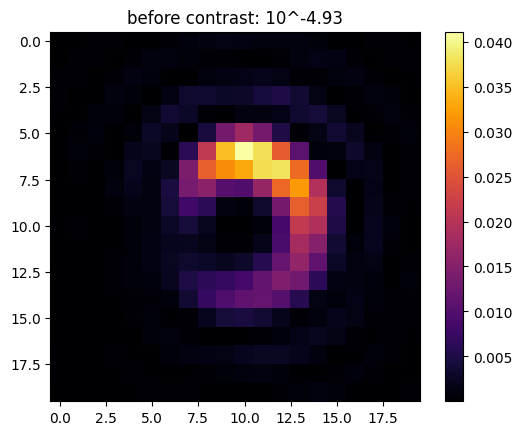

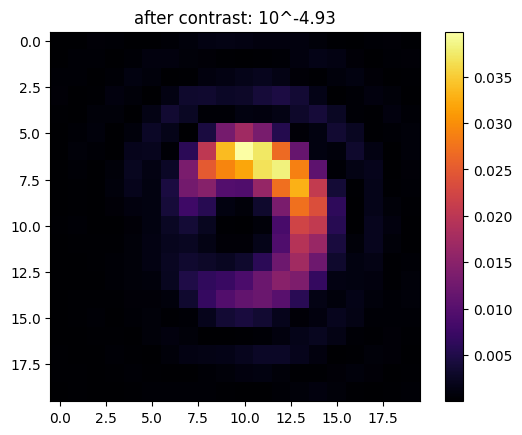

In [910]:
from train_job import NORMALIZERS

nudge_vec = metrics_data['dataset_meta']['nudge_vector']
delta_t = metrics_data['dataset_meta']['dataset_config']['delta_t']
dm_random_noise = metrics_data['dataset_meta']['dataset_config']['dm_random_noise']
N = 1

x_norm_func = NORMALIZERS[metrics_data['x_norm']['type']]
params = metrics_data['x_norm'].copy()
params.pop('type')

y_mean = metrics_data['y_norm']['mean']
y_std = metrics_data['y_norm']['std']

for _ in range(N):
        env.deformable_mirror.flatten()
        env.noise_gen_mirror.flatten()
        env.set_random_noise_dm(noise=1e-7)
        original = env.deformable_mirror.actuators.copy()

        original_contrast = env.get_contrast(delta_t=1e15)
        env.set_nudge_vectors(vectors=[nudge_vec])
        img1g, img2g, img3g = env.generate_diversity_images(delta_t=delta_t, noise_enabled=False)

        img1 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original + nudge_vec
        img2 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)

        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - nudge_vec
        img3 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        
        with torch.no_grad():
            imgs = np.array([img1, img2, img3])
            imgs = torch.asarray(imgs).unsqueeze(0)
            
            imgs_norm, _ = x_norm_func(imgs, **params)
            imgs_norm = np.transpose(imgs_norm, (0, 2, 3, 1))
            print(f"imgs_norm.shape = {imgs_norm.shape}")
            y_pred = model(imgs_norm)

            print(f"MSE: {np.linalg.norm(y_pred - (original - y_mean) / y_std)}")

            y_pred *= y_std
            y_pred -= y_mean

            print(y_pred)
            print(original)

        
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = original - np.array(y_pred[0])
        new_contrast = env.get_contrast(delta_t=1e15)

        img4 = torch.asarray(env.get_camera_image(delta_t=delta_t, noise_enabled=False), dtype=torch.float)
        plt.imshow(img1, cmap='inferno')
        plt.title(f"before contrast: 10^{np.log10(original_contrast):.02f}")
        plt.colorbar()
        plt.show()

        plt.imshow(img4, cmap='inferno')
        plt.title(f"after contrast: 10^{np.log10(new_contrast):.02f}")
        plt.colorbar()
        plt.show()

